---
title: "Taller - Sesion 4 - Series de Tiempo y Python IIE - UNAM"
author:
  - name: Luis E. Ascencio G. 
    orcid: 0009-0009-1694-5993
    email: luis.ascencio@cimat.mx
    affiliation: 
      - name: CIMAT
        city: Guanajuato
        state: Guanajuato
        url: https://www.cimat.mx
abstract: > 
  Este Notebook incluye una introduccion al manejo de Series de Tiempo con Python 
keywords:
  - Series de Tiempo
  - ARIMA
  - Python
  - R
  - Estadistica
license: "CC BY"
copyright: 
  holder: Luis E. Ascencio G.
  year: 2025
citation: 
  container-title: CIMAT
  volume: 1
  issue: 1
  doi: 000000/00000000
funding: "This work was supported by the Mexican Secretariat of Science, Humanities, Technology, and Innovation (SECIHTI, México) project CBF2023-2024-3976. Luis Enrique Ascencio Gorozpe is a doctoral student from the PhD in Probability and Statistics program, at Mathematics research center (CIMAT), he received  fellowship with number (CVU) 695305 from SECIHTI."
format:
  pdf:
    documentclass: scrartcl
    toc: true
    number-sections: true
    colorlinks: true
---

In [5]:
import numpy as np # Libreria Matematica basica
import pandas as pd # Libreria para manejo, manipulacion y visualizacion de datos 
from pandas import read_excel # funcion para leer archivos de excel


import matplotlib as mpl # Libreria para visualizacion de datos y graficas
import matplotlib.pyplot as plt   # Funcion para graficar 
import seaborn as sns             # Libreria para visualizacion de datos
from pandas.plotting import autocorrelation_plot

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import ArmaProcess

import session_info

In [6]:
import sktime
from sktime import datasets
from sktime.utils import plot_series
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [7]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.model_selection import temporal_train_test_split

# Datos

In [8]:
df = pd.read_csv('AirPassengers.csv')
df1 = read_excel('ClayBricks.xls')
df2 = read_excel('Electricity.xls')
df3 = read_excel('MilkProduction.xls')
df4 = read_excel('JapaneseCars.xls')
df5 = read_excel('HouseSales.xls')

In [9]:
df1

,Dates,Bricks
0,1956-03-01,189
1,1956-04-01,204
2,1956-05-01,208
3,1956-06-01,197
4,1956-07-01,187
...,...,...
150,1968-09-01,476
151,1968-10-01,443
152,1968-11-01,421
153,1968-12-01,472


In [10]:
dates=pd.to_datetime(df["Month"])
date1=pd.to_datetime(df1["Dates"])
date2=pd.to_datetime(df2["Month and year"])

In [11]:
airline=datasets.load_airline()

In [12]:
airline

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
           ...  
1960-08    606.0
1960-09    508.0
1960-10    461.0
1960-11    390.0
1960-12    432.0
Freq: M, Name: Number of airline passengers, Length: 144, dtype: float64

In [13]:
type(airline)

pandas.core.series.Series

In [14]:
df2

,Month and year,Kwh
0,1956-01-01,1254
1,1956-02-01,1290
2,1956-03-01,1379
3,1956-04-01,1346
4,1956-05-01,1535
...,...,...
471,1995-04-01,13032
472,1995-05-01,14268
473,1995-06-01,14473
474,1995-07-01,15359


In [15]:
ts=pd.Series(np.array(df["#Passengers"]),index=dates)
ts1=pd.Series(np.array(df1["Bricks"]),index=date1)
ts2=pd.Series(np.array(df2["Kwh"]),index=date2)
ts3=pd.Series(np.array(df3["Monthly Milk Production per Cow"]))
ts5=pd.Series(np.array(df5["HouseSales"]),index=df5["Month"])

In [16]:
ts2

Month and year
1956-01-01     1254
1956-02-01     1290
1956-03-01     1379
1956-04-01     1346
1956-05-01     1535
              ...  
1995-04-01    13032
1995-05-01    14268
1995-06-01    14473
1995-07-01    15359
1995-08-01    14457
Length: 476, dtype: int64

# SkTimes Graficador

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

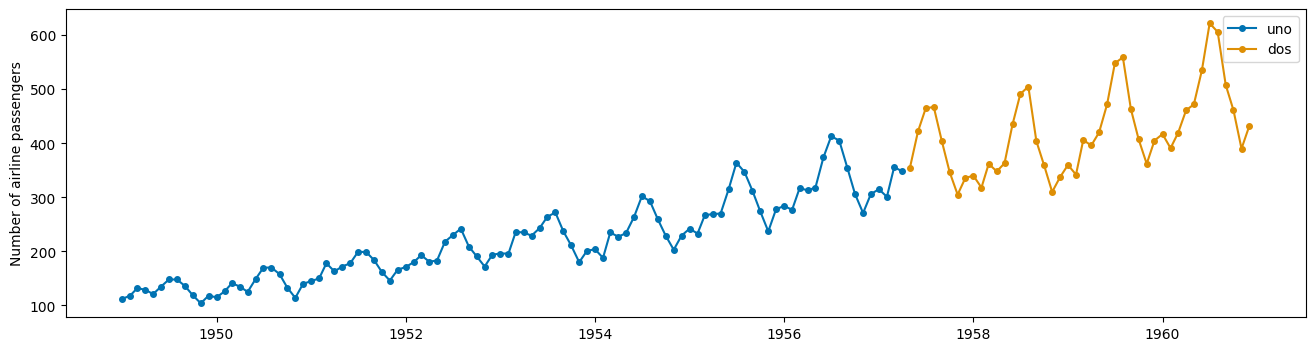

In [17]:
plot_series(airline[:100],airline[100:],labels=["uno","dos"])

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

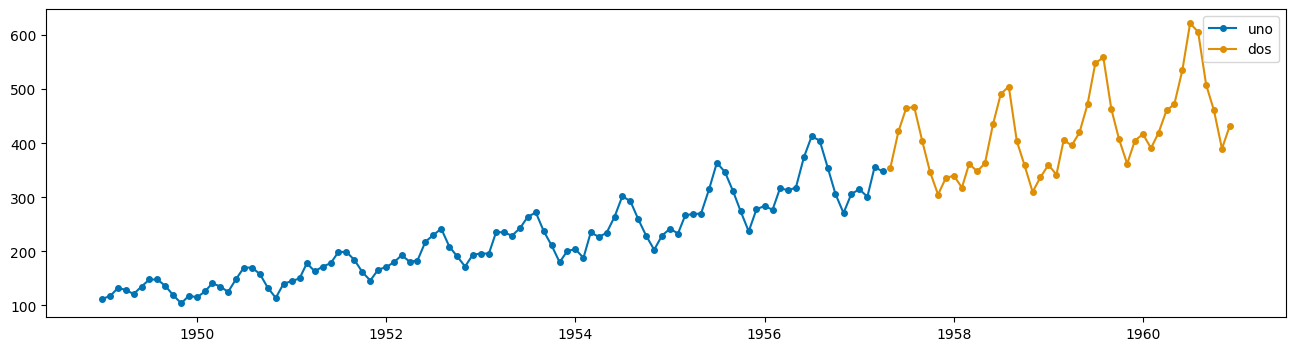

In [18]:
plot_series(ts[:100],ts[100:],labels=["uno","dos"])

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

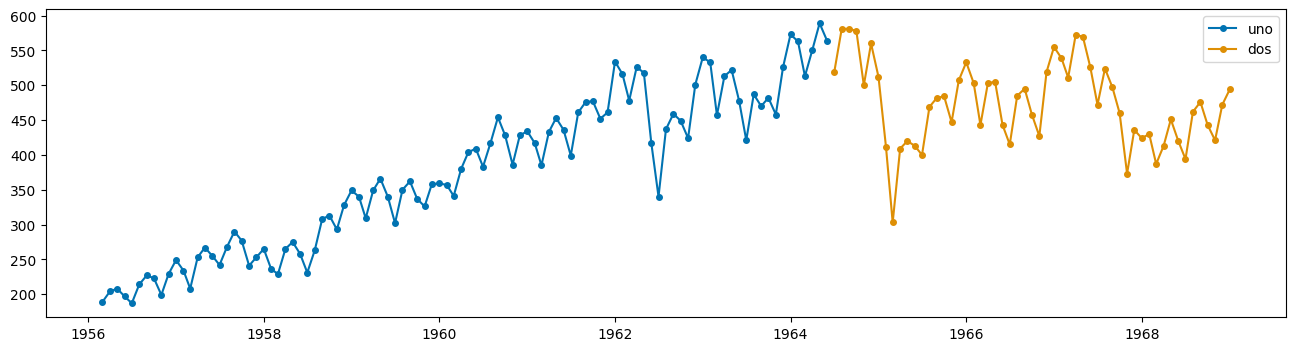

In [19]:
plot_series(ts1[:100],ts1[100:],labels=["uno","dos"])

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

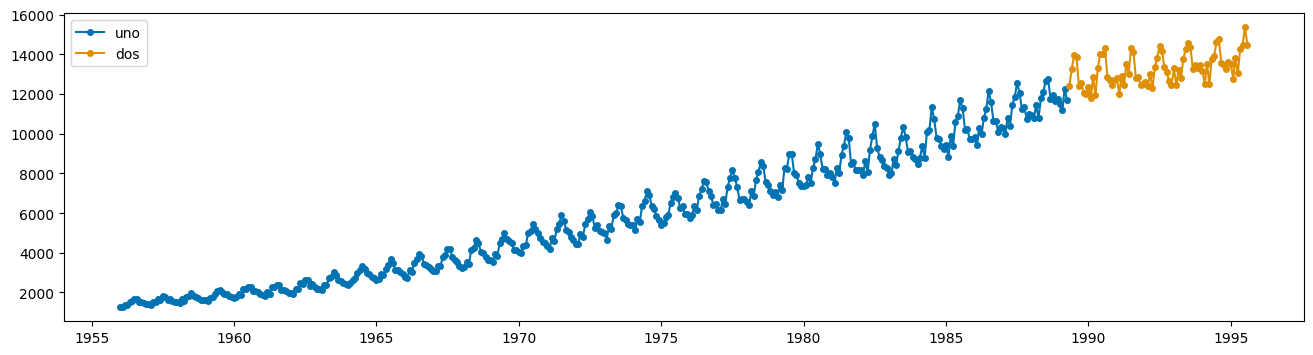

In [20]:
plot_series(ts2[:400],ts2[400:],labels=["uno","dos"])

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

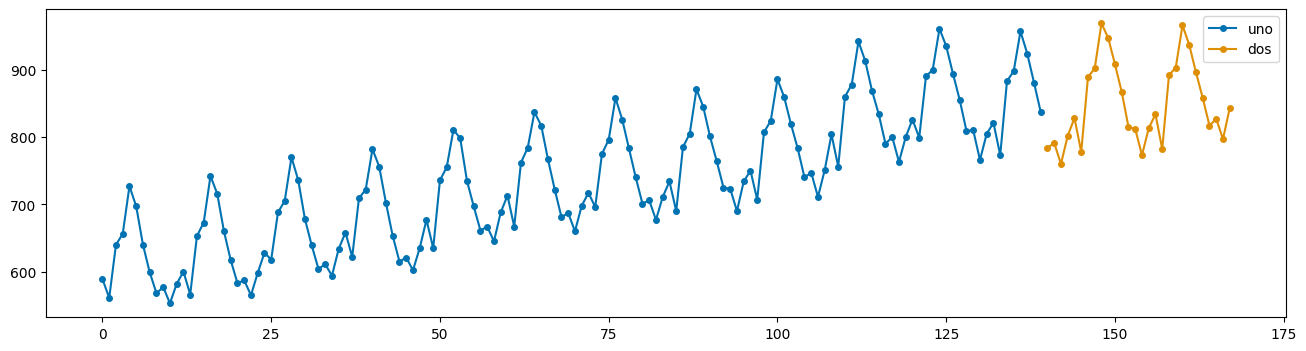

In [21]:
plot_series(ts3[:140],ts3[140:],labels=["uno","dos"])

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

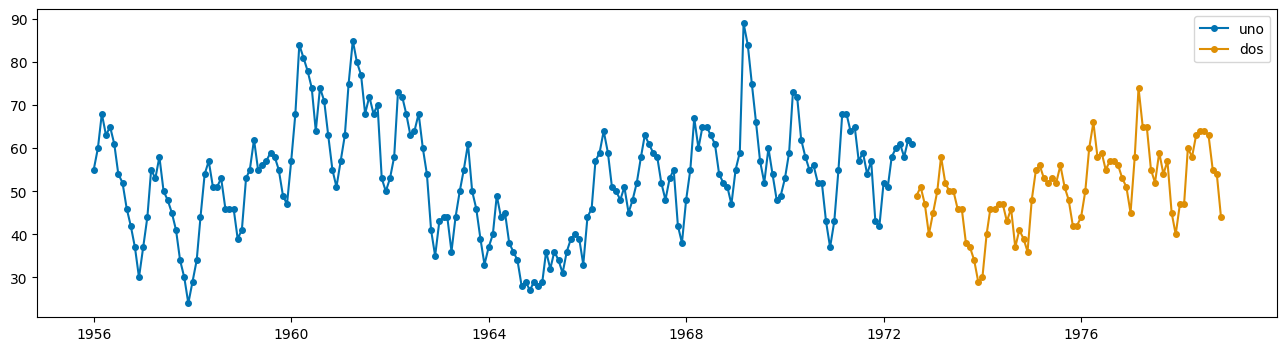

In [22]:
plot_series(ts5[:200],ts5[200:],labels=["uno","dos"])

## Prediccion Naive sin periodo

## Aerolineas

In [23]:
AirTrain,AirTest=temporal_train_test_split(airline)

In [24]:
predic_Air1=NaiveForecaster(strategy="last")
predic_Air2=NaiveForecaster(strategy="mean")
predic_Air3=NaiveForecaster(strategy="drift")

In [25]:
predic_Air1.fit(AirTrain)
predic_Air2.fit(AirTrain)
predic_Air3.fit(AirTrain)

/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


NaiveForecaster(strategy='drift')

In [26]:
x=np.arange(1,len(AirTest)+1)
y1=predic_Air1.predict(x)
y2=predic_Air2.predict(x)
y3=predic_Air3.predict(x)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

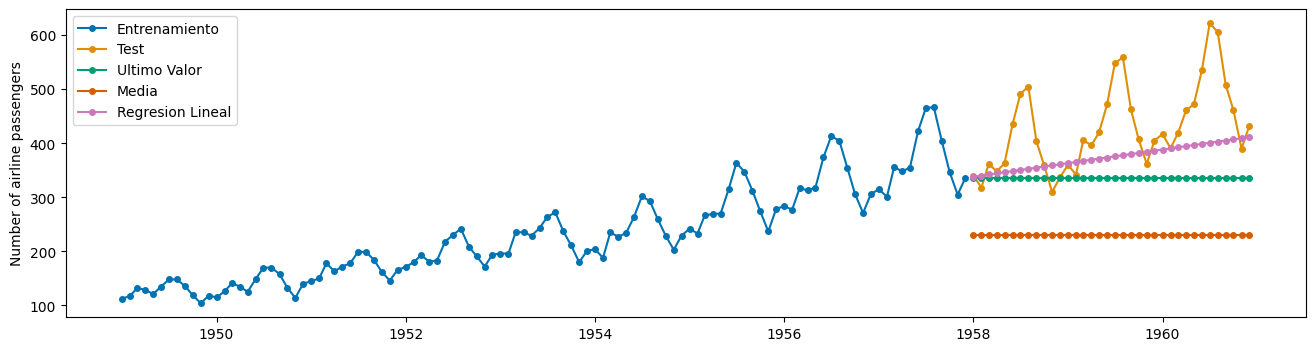

In [27]:
plot_series(AirTrain,AirTest,y1,y2,y3,labels=["Entrenamiento","Test","Ultimo Valor","Media","Regresion Lineal"])

## Ladrillos

In [28]:
ts1.index = ts1.index.to_period(freq="M")

In [29]:
ts1_Train,ts1_Test=temporal_train_test_split(ts1)

In [30]:
predic_ts11=NaiveForecaster(strategy="last")
predic_ts12=NaiveForecaster(strategy="mean")
predic_ts13=NaiveForecaster(strategy="drift")

In [31]:
predic_ts11.fit(ts1_Train)
predic_ts12.fit(ts1_Train)
predic_ts13.fit(ts1_Train)

/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


NaiveForecaster(strategy='drift')

In [32]:
x=np.arange(1,len(ts1_Test)+1)
y1=predic_ts11.predict(x)
y2=predic_ts12.predict(x)
y3=predic_ts13.predict(x)

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

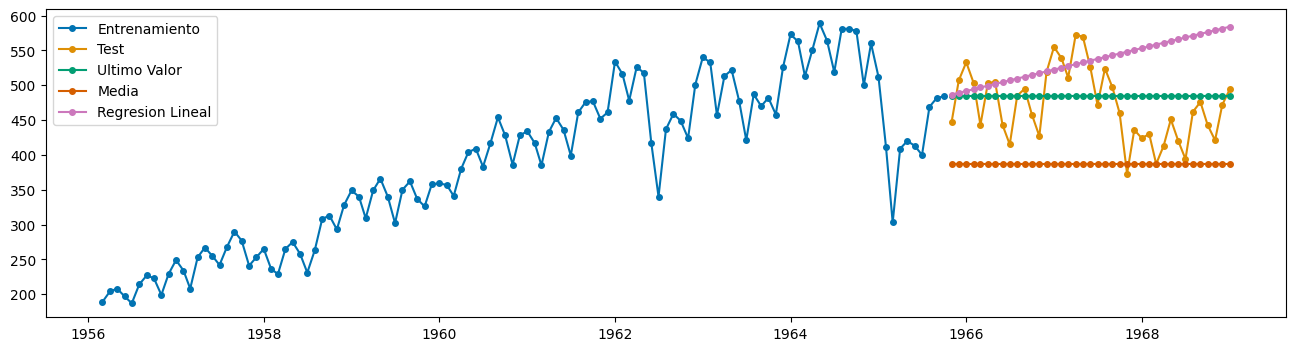

In [33]:
plot_series(ts1_Train,ts1_Test,y1,y2,y3,labels=["Entrenamiento","Test","Ultimo Valor","Media","Regresion Lineal"])

## Prediccion con Periodos

/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

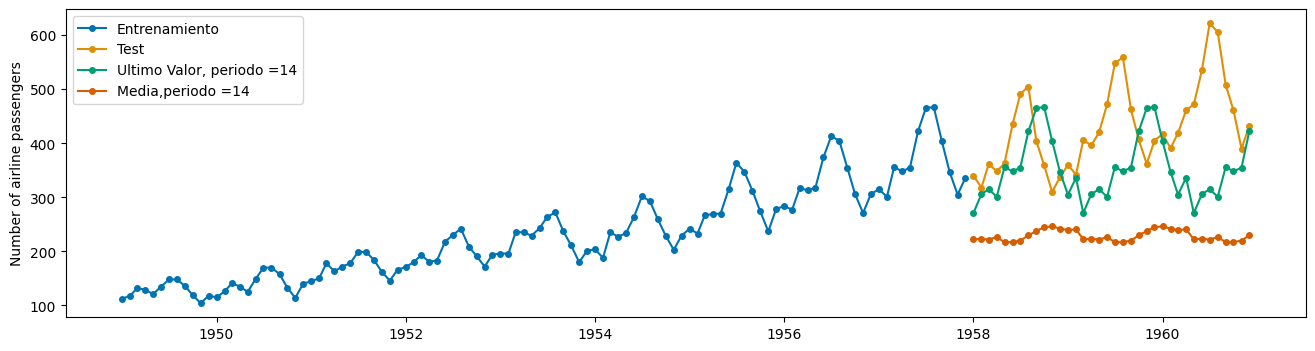

In [34]:
predic_Air21=NaiveForecaster(strategy="last",sp=14)
predic_Air22=NaiveForecaster(strategy="mean",sp=14)

predic_Air21.fit(AirTrain)
predic_Air22.fit(AirTrain)

x=np.arange(1,len(AirTest)+1) 
y21=predic_Air21.predict(x)
y22=predic_Air22.predict(x)

plot_series(AirTrain,AirTest,y21,y22,labels=["Entrenamiento","Test","Ultimo Valor, periodo =14","Media,periodo =14"])

/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)
/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/skbase/base/_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


(<Figure size 1600x400 with 1 Axes>, <Axes: >)

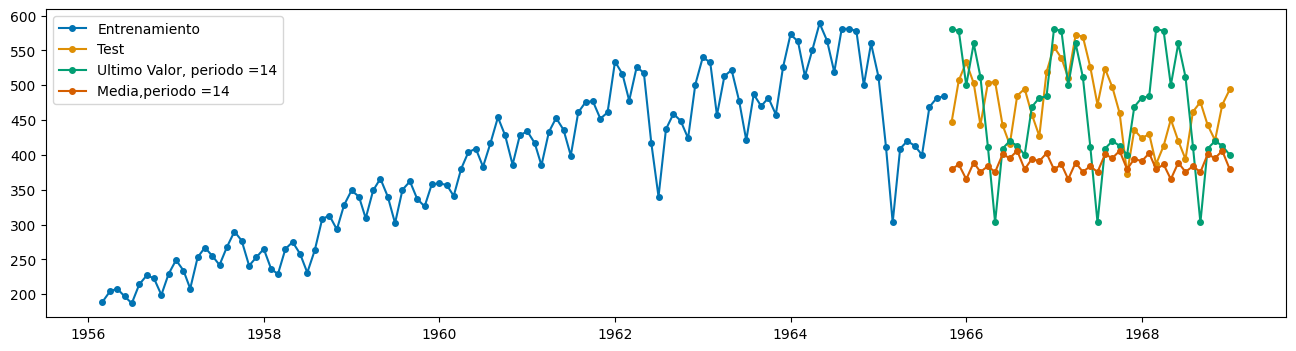

In [35]:
predic_ts1_21=NaiveForecaster(strategy="last",sp=14)
predic_ts1_22=NaiveForecaster(strategy="mean",sp=14)

predic_ts1_21.fit(ts1_Train)
predic_ts1_22.fit(ts1_Train)

x=np.arange(1,len(ts1_Test)+1) 
y21=predic_ts1_21.predict(x)
y22=predic_ts1_22.predict(x)

plot_series(ts1_Train,ts1_Test,y21,y22,labels=["Entrenamiento","Test","Ultimo Valor, periodo =14","Media,periodo =14"])

In [36]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.utils import AirPassengersDF

/home/leag555/.cache/pypoetry/virtualenvs/py-ts-code-o-h5Vef7-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
df.columns=["ds","y"]

In [38]:
df

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [39]:
df.insert(0, 'unique_id', len(df)*["AirPassengers"])

In [40]:
df

,unique_id,ds,y
0,AirPassengers,1949-01,112
1,AirPassengers,1949-02,118
2,AirPassengers,1949-03,132
3,AirPassengers,1949-04,129
4,AirPassengers,1949-05,121
...,...,...,...
139,AirPassengers,1960-08,606
140,AirPassengers,1960-09,508
141,AirPassengers,1960-10,461
142,AirPassengers,1960-11,390


In [41]:
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='ME',
)

sf.fit(df)
dff_forecast=sf.predict(h=12, level=[95])

In [42]:
dff_forecast

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,AirPassengers,1960-12-31,444.309570,421.279327,467.339813
1,AirPassengers,1961-01-31,418.213745,390.227631,446.199829
2,AirPassengers,1961-02-28,446.243408,412.910034,479.576782
3,AirPassengers,1961-03-31,488.234222,450.621368,525.847107
4,AirPassengers,1961-04-30,499.237061,457.694824,540.779297
5,AirPassengers,1961-05-31,562.236206,517.130981,607.341431
6,AirPassengers,1961-06-30,649.236450,600.822449,697.650513
7,AirPassengers,1961-07-31,633.236389,581.727783,684.744934
8,AirPassengers,1961-08-31,535.236389,480.808289,589.664490
9,AirPassengers,1961-09-30,488.236389,431.037781,545.434998


In [43]:
date_sf=pd.to_datetime(dff_forecast["ds"])
ts_predic_sf=pd.Series(np.array(dff_forecast["AutoARIMA"]),index=date_sf)
ts_predic_sf_h=pd.Series(np.array(dff_forecast["AutoARIMA-hi-95"]),index=date_sf)
ts_predic_sf_l=pd.Series(np.array(dff_forecast["AutoARIMA-lo-95"]),index=date_sf)

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

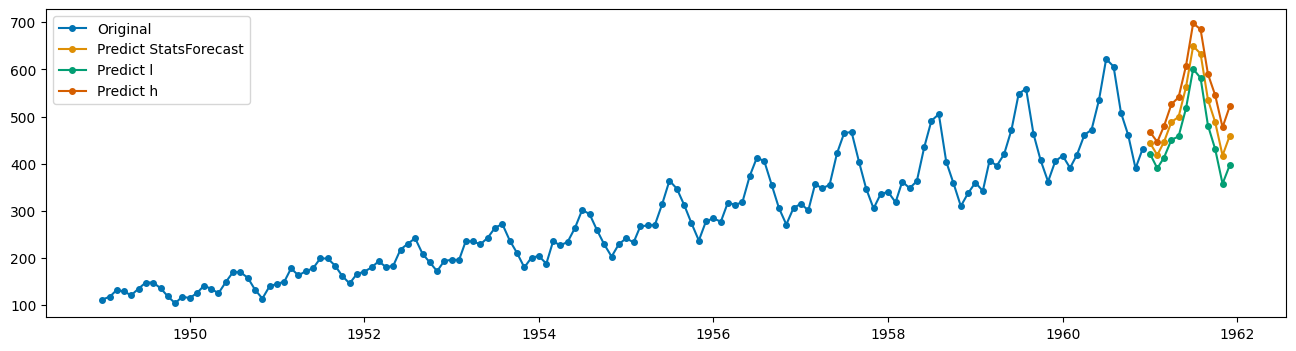

In [44]:
plot_series(ts,ts_predic_sf,ts_predic_sf_l,ts_predic_sf_h,labels=["Original","Predict StatsForecast","Predict l","Predict h"])

(<Figure size 1600x400 with 1 Axes>, <Axes: >)

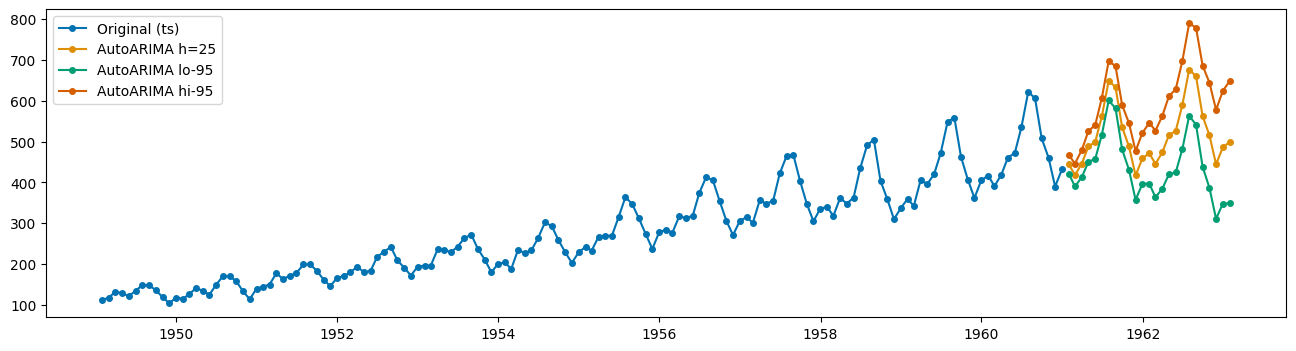

In [45]:
# Ajustar AutoARIMA a la serie ts y predecir h=25, luego graficar resultados
# (usa imports y variables ya existentes en el notebook)

# Preparar dataframe para StatsForecast (ds en month-end para consistencia con freq='ME')
df_sf = pd.DataFrame({
    "unique_id": "AirPassengers",
    "ds": ts.index.to_period("M").to_timestamp("M"),
    "y": ts.values
})

# Crear y ajustar modelo AutoARIMA (periodicidad mensual)
sf_arima = StatsForecast(models=[AutoARIMA(season_length=12)], freq='ME')
sf_arima.fit(df_sf)

# Predecir horizonte h=25
h = 25
dff_pred25 = sf_arima.predict(h=h, level=[95])

# Convertir predicciones a Series con índice de fechas
date_pred25 = pd.to_datetime(dff_pred25["ds"])
ts_pred25 = pd.Series(dff_pred25["AutoARIMA"].values, index=date_pred25)
ts_pred25_lo = pd.Series(dff_pred25["AutoARIMA-lo-95"].values, index=date_pred25)
ts_pred25_hi = pd.Series(dff_pred25["AutoARIMA-hi-95"].values, index=date_pred25)

# Preparar serie original con índice month-end para graficar en la misma escala temporal
ts_monthend = ts.copy()
ts_monthend.index = ts_monthend.index.to_period("M").to_timestamp("M")

# Graficar serie original y pronóstico con bandas de incertidumbre
plot_series(ts_monthend, ts_pred25, ts_pred25_lo, ts_pred25_hi,
            labels=["Original (ts)", f"AutoARIMA h={h}", "AutoARIMA lo-95", "AutoARIMA hi-95"])

In [46]:
session_info.show(html=False)

-----
matplotlib          3.10.7
numpy               2.3.4
pandas              2.3.3
seaborn             0.13.2
session_info        v1.0.1
sklearn             1.7.2
sktime              0.38.5
statsforecast       2.0.2
statsmodels         0.14.5
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.11.15 (main, Mar  8 2026, 22:57:40) [GCC 15.2.1 20260209]
Linux-6.18.12-1-MANJARO-x86_64-with-glibc2.43
-----
Session information updated at 2026-03-08 23:20
